In [1]:
%load_ext autoreload
%autoreload 2
import h5py 
import scipy 
import numpy as np 
import matplotlib.pyplot as plt 
from spts.scripts import cxd_to_h5
import config




In [5]:
    #_, _, _, _ = cxd_to_h5.estimate_background('/home/pat/spts-testing/spts-data/data00657.cxd', i, read_cache=False)
    
    
    #plt.xlim([-25,25])

In [2]:

config.DATA_DIR



PosixPath('/home/pat/spts-ana/data')

In [2]:
_, _, _, _, bins, hist= cxd_to_h5.estimate_background('../spts-data/data00657.cxd', 10, read_cache=False, hist_bins=100)
bin_mids = (bins[:-1] + bins[1:]) / 2.0


#save this out to h5? maybe just hist, bins and the 1/e^2 val.
def gpdf(x, mu, sigma):
    return (1.0 / (sigma * np.sqrt(2*np.pi))) * np.exp(-(x - mu)**2 / (2*sigma**2))
    
popt, pcov = scipy.optimize.curve_fit(gpdf, bin_mids, hist)

xplot = np.linspace(bins[0], bins[-1], 1000)
plt.figure()
plt.bar(bin_mids, hist, width=np.diff(bins), align='center', alpha=0.5, label='Histogram (density)')
plt.plot(xplot, gpdf(xplot, *popt), 'r', lw=2,linestyle='dashed', label='Gaussian PDF fit')
plt.axhline((1.0 / (popt[1] * np.sqrt(2*np.pi)))/(np.e**2))
plt.axvline(popt[0]+2*popt[1])

print((1.0 / (popt[1] * np.sqrt(2*np.pi)))/(np.e**2), popt[0]+2*popt[1])

*************************************
*   Background correction section   *
*************************************
No cached background found. Generating new cache.


FileNotFoundError: [Errno 2] No such file or directory: '../spts-data/data00657.cxd'

*************************************
*   Background correction section   *
*************************************
No cached background found. Generating new cache.
Calculating background estimate by mean of buffer...done.
Found 178865 bad pixels and 4015439 good pixels.
Mean over mean background = 99
Std dev over mean background = 21
Writing out h5...done.
0.016540510147710977 6.247049299822512
*************************************
*   Background correction section   *
*************************************
No cached background found. Generating new cache.
Calculating background estimate by mean of buffer...done.
Found 178865 bad pixels and 4015439 good pixels.
Mean over mean background = 99
Std dev over mean background = 21
Writing out h5...done.
0.016601189759590997 6.222094099569581
*************************************
*   Background correction section   *
*************************************
No cached background found. Generating new cache.
Calculating background estimate by mean 

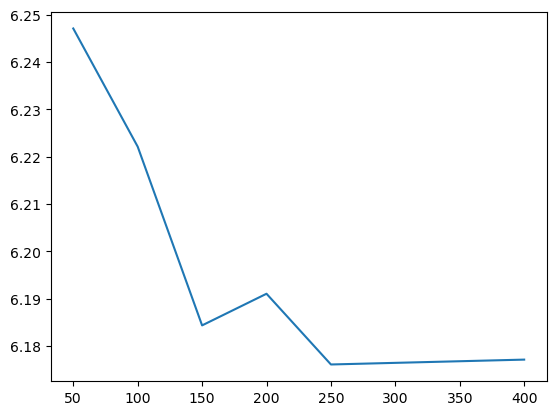

In [29]:

#how does n bins change the minimum background? not much.
x = []
for i in [50, 100, 150, 200, 250, 400]:
    _, _, _, _, bins, hist, mu_mle, sigma_mle = cxd_to_h5.estimate_background('/home/pat/spts-testing/spts-data/data00657.cxd', 10, read_cache=False, hist_bins=i)
    bin_mids = (bins[:-1] + bins[1:]) / 2.0
    
    def gpdf(x, mu, sigma):
        return (1.0 / (sigma * np.sqrt(2*np.pi))) * np.exp(-(x - mu)**2 / (2*sigma**2))
        
    popt, pcov = scipy.optimize.curve_fit(gpdf, bin_mids, hist)
    
    xplot = np.linspace(bins[0], bins[-1], 1000)
    #plt.figure()
    #plt.bar(bin_mids, hist, width=np.diff(bins), align='center', alpha=0.5, label='Histogram (density)')
    #plt.plot(xplot, gpdf(xplot, *popt), 'r', lw=2,linestyle='dashed', label='Gaussian PDF fit')
    #plt.axhline((1.0 / (popt[1] * np.sqrt(2*np.pi)))/(np.e**2))
    #plt.axvline(popt[0]+2*popt[1])

    x.append(popt[0]+2*popt[1])
    print((1.0 / (popt[1] * np.sqrt(2*np.pi)))/(np.e**2), popt[0]+2*popt[1])
plt.figure()
plt.plot([50, 100, 150, 200, 250, 400], x)


[ 0.42195062 -0.30679597  4.85060952  2.55626896]


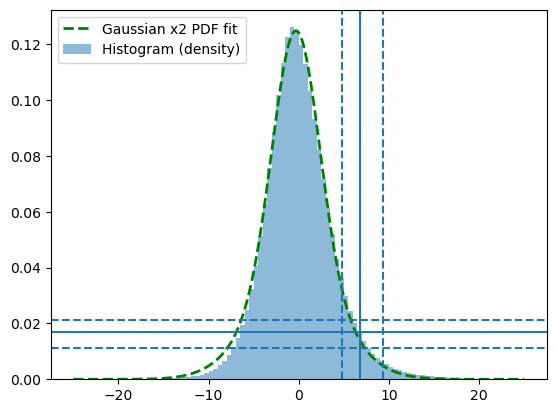

In [22]:



def mix2_gpdf(x, w, mu, sigma1, sigma2):
    g1 = (1.0 / (sigma1 * np.sqrt(2*np.pi))) * np.exp(-(x - mu)**2 / (2*sigma1**2))
    g2 = (1.0 / (sigma2 * np.sqrt(2*np.pi))) * np.exp(-(x - mu)**2 / (2*sigma2**2))
    return w * g1 + (1 - w) * g2

popt, pcov = scipy.optimize.curve_fit(mix2_gpdf, bin_mids, hist)
print(popt)
xplot = np.linspace(bins[0], bins[-1], 1000)
plt.figure()
plt.bar(bin_mids, hist, width=np.diff(bins), align='center', alpha=0.5, label='Histogram (density)')
plt.plot(xplot, mix2_gpdf(xplot, *popt), 'g', lw=2,linestyle='dashed', label='Gaussian x2 PDF fit')


plt.axhline((1.0 / (popt[2] * np.sqrt(2*np.pi)))/(np.e**2), linestyle='dashed')
plt.axhline((1.0 / (popt[3] * np.sqrt(2*np.pi)))/(np.e**2), linestyle='dashed')
plt.axhline( popt[0]*(1.0 / (popt[2] * np.sqrt(2*np.pi)))/(np.e**2) + (1-popt[0])*(1.0 / (popt[3] * np.sqrt(2*np.pi)))/(np.e**2))

plt.axvline(popt[1]+2*popt[2], linestyle='dashed')
plt.axvline(popt[1]+2*popt[3], linestyle='dashed')
plt.axvline( popt[0]*(popt[1]+2*popt[2]) + (1-popt[0])*(popt[1]+2*popt[3]))

plt.legend()
plt.show()